# Reporte de Reducción de Espectros de Galaxias en Cúmulos de Abell
## Curso de Espectroscopía — OAN San Pedro Mártir, 2007 agosto
### Jennifer Grisales — Universidad de Guanajuato, 2026

---

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import os, re, warnings
warnings.filterwarnings('ignore')

# Estilo de plots
plt.rcParams.update({
    'figure.figsize': (12, 4),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# Directorio base (notebook debe estar en practice/)
BASE = os.path.dirname(os.path.abspath('__file__'))
NOCHE2 = os.path.join(BASE, 'noche2')
INDIV  = os.path.join(NOCHE2, 'individual')
MUESTRAS = os.path.join(BASE, 'muestras')
DB = os.path.join(NOCHE2, 'database')

print(f"Directorio base: {BASE}")
print(f"Noche 2: {NOCHE2}")
print(f"Individual: {INDIV}")

Directorio base: /home/jennifer/practice
Noche 2: /home/jennifer/practice/noche2
Individual: /home/jennifer/practice/noche2/individual


## 1. Introducción

Las observaciones fueron realizadas el **13 de agosto de 2007** en el Observatorio Astronómico Nacional de San Pedro Mártir (OAN-SPM), Baja California, México, utilizando el telescopio de **2.1 m** con el espectrógrafo **Boller & Chivens (B&Ch)**.

| Parámetro | Valor |
|---|---|
| Telescopio | OAN/SPM 2.1 m |
| Instrumento | Boller & Chivens |
| Detector | Thomson 2K ($1024 \times 2048$ px) |
| Grism | 27 |
| Lámpara de calibración | CuHeNeAr |
| Rango espectral | ~4600 – 7200 Å |
| Ganancia | 0.5 e⁻/ADU |
| Latitud del observatorio | +31° 02' 39" N |
| Longitud del observatorio | 115° 27' 49" W |
| Altitud | 2800 m |

Se observaron galaxias en cuatro cúmulos de Abell (A0084, A2170, A2243 y A2469) junto con la estrella estándar de velocidad radial Kopff 27 (IC 4665 27). La reducción se realizó con **IRAF** (v2.16.1) y el paquete **RVSAO** (v2.8.2) para la medición de velocidades radiales mediante correlación cruzada (`xcsao`).

## 2. Objetos Observados

La siguiente tabla resume los objetos observados y sus propiedades publicadas en las bases de datos NED y SIMBAD:

In [23]:
# Tabla de objetos observados
objetos = Table()
objetos['Objeto'] = ['Kopff 27', 'A0084-01', 'A2170-03', 'A2243-04', 'A2469-12']
objetos['AR (J2000)'] = ['17:43:55.8', '00:41:14.1', '16:16:56.2', '17:01:53.0', '22:40:01.8']
objetos['DEC (J2000)'] = ['+05:24:48', '+21:17:38', '+23:17:15', '+35:03:02', '+12:10:56']
objetos['Nombre NED/SIMBAD'] = ['IC 4665 27', 'LEDA 1647026', 'LEDA 1684720', 'ACO 2243', 'LEDA 1405153']
objetos['Tipo'] = ['Estrella (A3V)', 'Galaxia', 'Galaxia', 'Galaxia (BCG)', 'Galaxia']
objetos['cz_pub (km/s)'] = [-15.05, 12592, 29532, 30129, 37601]
objetos['Tipo z'] = ['spec', 'photo-z', 'spec', 'spec', 'photo-z']
objetos['Ref. z'] = ['Gaia DR3', 'Bilicki+2014 (2MPZ)', 'NED/spec', 'NED/spec', 'Bilicki+2014 (2MPZ)']
objetos['EXPTIME (s)'] = [150, 1200, 1200, 1200, 1200]

print('NOTA: Los redshifts tipo photo-z tienen incertidumbre tipica de ~4500 km/s (Bilicki et al. 2014, ApJS, 210, 9)')
print('      Los redshifts tipo spec son espectroscopicos con incertidumbre de ~30-100 km/s')
print()
objetos.pprint_all()

NOTA: Los redshifts tipo photo-z tienen incertidumbre tipica de ~4500 km/s (Bilicki et al. 2014, ApJS, 210, 9)
      Los redshifts tipo spec son espectroscopicos con incertidumbre de ~30-100 km/s

 Objeto  AR (J2000) DEC (J2000) Nombre NED/SIMBAD      Tipo      cz_pub (km/s)  Tipo z        Ref. z       EXPTIME (s)
-------- ---------- ----------- ----------------- -------------- ------------- ------- ------------------- -----------
Kopff 27 17:43:55.8   +05:24:48        IC 4665 27 Estrella (A3V)        -15.05    spec            Gaia DR3         150
A0084-01 00:41:14.1   +21:17:38      LEDA 1647026        Galaxia       12592.0 photo-z Bilicki+2014 (2MPZ)        1200
A2170-03 16:16:56.2   +23:17:15      LEDA 1684720        Galaxia       29532.0    spec            NED/spec        1200
A2243-04 17:01:53.0   +35:03:02          ACO 2243  Galaxia (BCG)       30129.0    spec            NED/spec        1200
A2469-12 22:40:01.8   +12:10:56      LEDA 1405153        Galaxia       37601.0 photo-z Bi

### Imágenes de los objetos (NED/SIMBAD)

A continuación se muestran imágenes de campo de cada objeto. Estas imágenes se encuentran en la carpeta `muestras/` con el nombre correspondiente a la columna `nombreSIMBAD`.

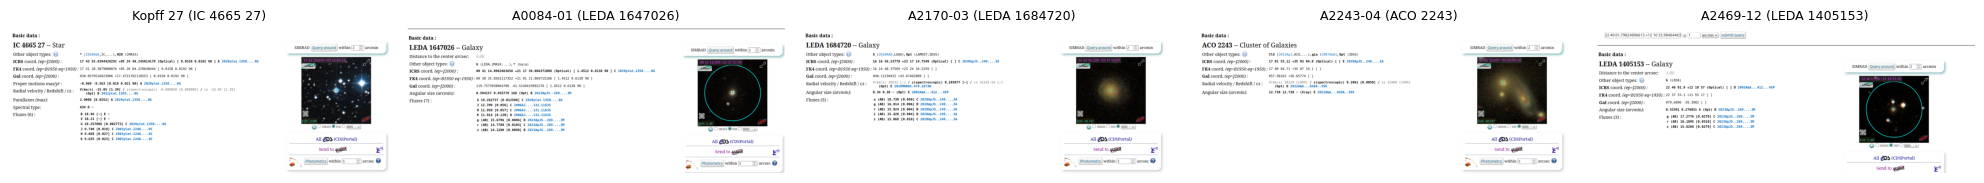

In [10]:
# Mostrar imágenes de los objetos si existen
nombres_img = ['kopff27', 'LEDA1647026', 'LEDA1684720', 'ACO2243', 'LEDA1405153']
titulos_img = ['Kopff 27 (IC 4665 27)', 'A0084-01 (LEDA 1647026)',
               'A2170-03 (LEDA 1684720)', 'A2243-04 (ACO 2243)', 'A2469-12 (LEDA 1405153)']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, nombre, titulo in zip(axes, nombres_img, titulos_img):
    img_path = os.path.join(MUESTRAS, f'{nombre}.png')
    if os.path.exists(img_path):
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(titulo, fontsize=9)
    else:
        ax.text(0.5, 0.5, f'{nombre}.png\nno encontrado', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(titulo, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Resumen de la Reducción

La reducción de los espectros se realizó siguiendo el procedimiento estándar en IRAF para espectroscopía de rendija larga. Los pasos principales fueron:

1. **Corrección de BIAS:** Se combinaron las imágenes de BIAS de las 5 noches con `zerocombine` y se restaron de todas las imágenes con `ccdproc`.

2. **Corrección de Flat Field:** Se combinaron los dome flats con `flatcombine`, se normalizaron con `response`, y se aplicaron a las imágenes con `ccdproc`.

3. **Extracción de espectros:** Se utilizó `apall` para extraer los espectros 1D de las imágenes 2D, definiendo las aperturas y restando el cielo de fondo.

4. **Calibración en longitud de onda:** Se identificaron líneas de emisión en las lámparas de CuHeNeAr con `identify`, se propagó la solución a las demás lámparas con `reidentify`, y se aplicó la solución de dispersión a los espectros de objetos con `dispcor`.

5. **Corrección por velocidad heliocéntrica/baricéntrica:** Se verificó que los headers contuvieran las keywords necesarias (`SITELAT`, `SITELONG`, `SITEELEV`, `RA`, `DEC`, `DATE-OBS`, `UT`, `EPOCH`). Se corrigieron las coordenadas de los objetos en los headers.

6. **Suma de exposiciones:** Se combinaron las exposiciones individuales de cada objeto con `scombine` para mejorar la relación señal-a-ruido.

7. **Medición de velocidades radiales:** Se utilizó `xcsao` (paquete RVSAO) para medir velocidades radiales mediante correlación cruzada con templates estelares y de galaxias.

> **Nota:** Insertar screenshots relevantes de cada paso (ds9, identify, apall, etc.) como imágenes `.png` en la carpeta `muestras/` y referenciarlos con `![descripcion](muestras/nombre.png)`.

## 4. Verificación de la Calibración en Longitud de Onda

### 4.1 Lectura de espectros IRAF multispec

Los archivos `.ms.fits` de IRAF almacenan la solución de longitud de onda en keywords `WAT2_*` del header, utilizando un formato multispec. La siguiente función extrae el arreglo de longitudes de onda a partir de estos keywords.

In [11]:
def read_multispec_wavelength(fits_path):
    """
    Lee un espectro IRAF multispec y retorna (wavelength, flux).
    Maneja funciones de dispersión lineales (dtype=0) y
    polinomiales Chebyshev/Legendre (dtype=1,2).
    """
    hdu = fits.open(fits_path)
    header = hdu[0].header
    data = hdu[0].data
    hdu.close()

    # Extraer datos: puede ser 1D, 2D o 3D
    if data.ndim == 3:
        flux = data[0, 0, :]
    elif data.ndim == 2:
        flux = data[0, :]
    else:
        flux = data

    npix = len(flux)

    # Intentar leer WAT2 (solución multispec)
    wat2 = ''
    for key in sorted(header.keys()):
        if key.startswith('WAT2_'):
            wat2 += header[key]

    if wat2:
        # Buscar spec1 = "ap ... dtype w1 dw nw z ..."
        match = re.search(r'spec1\s*=\s*"(.+?)"', wat2)
        if match:
            parts = match.group(1).split()
            # parts: ap beam dtype w1 dw nw z aplow aphigh [function...]
            dtype = int(float(parts[2]))
            if dtype == 0:
                # Linear: w1, dw, nw
                w1 = float(parts[3])
                dw = float(parts[4])
                nw = int(float(parts[5]))
                # No aplicar corrección por z; los espectros solo están
                # calibrados en longitud de onda observada.
                wave = w1 + dw * np.arange(nw)
                return wave[:npix], flux
            elif dtype == 2:
                # Non-linear with function type
                w1 = float(parts[3])
                dw = float(parts[4])
                nw = int(float(parts[5]))
                # Fallback: try CRVAL1/CDELT1
                pass

    # Fallback: use standard WCS keywords
    if 'CRVAL1' in header and ('CDELT1' in header or 'CD1_1' in header):
        crval1 = header['CRVAL1']
        cdelt1 = header.get('CDELT1', header.get('CD1_1', 1.0))
        crpix1 = header.get('CRPIX1', 1.0)
        wave = crval1 + cdelt1 * (np.arange(npix) - (crpix1 - 1))
        return wave, flux

    # Último recurso: píxeles
    print(f"ADVERTENCIA: No se pudo extraer WCS de {fits_path}, usando píxeles.")
    return np.arange(npix), flux

# Test con un espectro
test_file = os.path.join(NOCHE2, '2026o_tbfic_l.ms.fits')
if os.path.exists(test_file):
    w, f = read_multispec_wavelength(test_file)
    print(f"Rango de longitud de onda: {w[0]:.1f} - {w[-1]:.1f} Å ({len(w)} píxeles)")
else:
    print(f"Archivo no encontrado: {test_file}")

Rango de longitud de onda: 4599.9 - 7217.6 Å (2034 píxeles)


### 4.2 Residuos de la solución de `identify`

Se analizan los residuos de la calibración en longitud de onda para las lámparas de CuHeNeAr asociadas a la estrella Kopff 27 (archivo `2027a_tbfi.ms`). Los residuos se calculan como $\Delta\lambda = \lambda_{\text{ajustado}} - \lambda_{\text{catálogo}}$.

Lámpara 2027a: 36 líneas, RMS = 0.0898 Å, error vel. ~ 4.5 km/s
Lámpara 2027a2: 36 líneas, RMS = 0.0896 Å, error vel. ~ 4.5 km/s


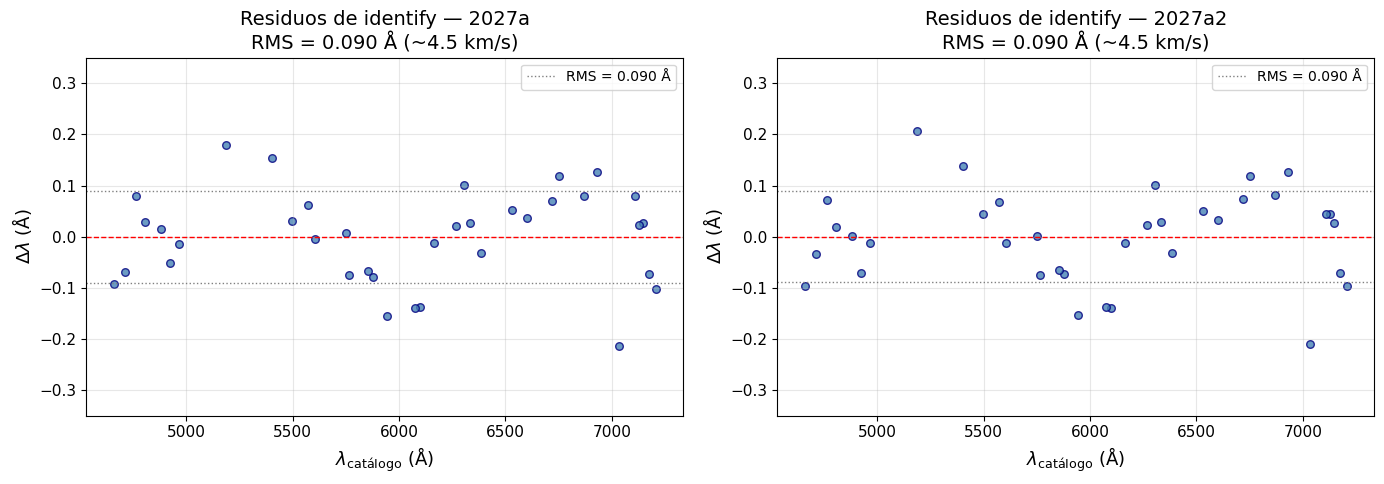

In [12]:
def parse_identify_solution(db_path):
    """Lee un archivo de solución de identify de IRAF y extrae
    las líneas identificadas con sus residuos."""
    with open(db_path, 'r') as f:
        lines = f.readlines()

    pixels = []
    lambda_fit = []
    lambda_cat = []
    line_id = []

    in_features = False
    for line in lines:
        line = line.strip()
        if line.startswith('features'):
            in_features = True
            continue
        if in_features:
            if line.startswith('function') or line.startswith('order') or \
               line.startswith('sample') or line.startswith('coefficients') or \
               line.startswith('naverage') or line.startswith('niterate') or \
               line.startswith('low_reject') or line.startswith('high_reject') or \
               line.startswith('grow') or not line:
                in_features = False
                continue
            parts = line.split()
            if len(parts) >= 6:
                pixels.append(float(parts[0]))
                lambda_fit.append(float(parts[1]))
                lambda_cat.append(float(parts[2]))
                line_id.append(' '.join(parts[5:]))

    return np.array(pixels), np.array(lambda_fit), np.array(lambda_cat), line_id

# Leer soluciones de las lámparas de Kopff 27
lamp1_path = os.path.join(DB, 'id2027a_tbfi.ms')
lamp2_path = os.path.join(DB, 'id2027a2_tbfi.ms')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, label in zip(axes, [lamp1_path, lamp2_path], ['2027a', '2027a2']):
    if os.path.exists(path):
        pix, lfit, lcat, ids = parse_identify_solution(path)
        residuos = lfit - lcat
        rms = np.sqrt(np.mean(residuos**2))
        vel_err = rms / np.mean(lcat) * 3e5  # Error en km/s

        ax.scatter(lcat, residuos, c='steelblue', s=30, edgecolors='navy', alpha=0.8)
        ax.axhline(0, color='red', ls='--', lw=1)
        ax.axhline(rms, color='gray', ls=':', lw=1, label=f'RMS = {rms:.3f} Å')
        ax.axhline(-rms, color='gray', ls=':', lw=1)
        ax.set_xlabel('$\lambda_{\mathrm{catálogo}}$ (Å)')
        ax.set_ylabel('$\Delta\lambda$ (Å)')
        ax.set_title(f'Residuos de identify — {label}\nRMS = {rms:.3f} Å (~{vel_err:.1f} km/s)')
        ax.legend(fontsize=10)
        ax.set_ylim(-0.35, 0.35)
        ax.grid(True, alpha=0.3)

        print(f"Lámpara {label}: {len(pix)} líneas, RMS = {rms:.4f} Å, error vel. ~ {vel_err:.1f} km/s")
    else:
        print(f"No encontrado: {path}")

plt.tight_layout()
plt.show()

### 4.3 Interpretación de los residuos

El RMS de la calibración en longitud de onda es de ~0.09 Å para ambas lámparas asociadas a Kopff 27. A una longitud de onda central de ~5800 Å, esto corresponde a un error sistemático en velocidad de:

$$\Delta v = \frac{\Delta\lambda}{\lambda} \cdot c \approx \frac{0.09}{5800} \times 3 \times 10^5 \approx 5 \text{ km/s}$$

Este valor es significativamente menor que los errores reportados por `xcsao` (~30–70 km/s), lo que indica que la calibración en longitud de onda **no es la fuente dominante de incertidumbre** en las velocidades radiales. La estabilidad entre las dos lámparas (soluciones prácticamente idénticas) confirma la consistencia instrumental durante la noche.

## 5. Espectros Finales Calibrados

A continuación se presentan los espectros calibrados en longitud de onda de todos los objetos observados. Los archivos `*_l.ms.fits` contienen los espectros con la solución de dispersión aplicada (`dispcor`).

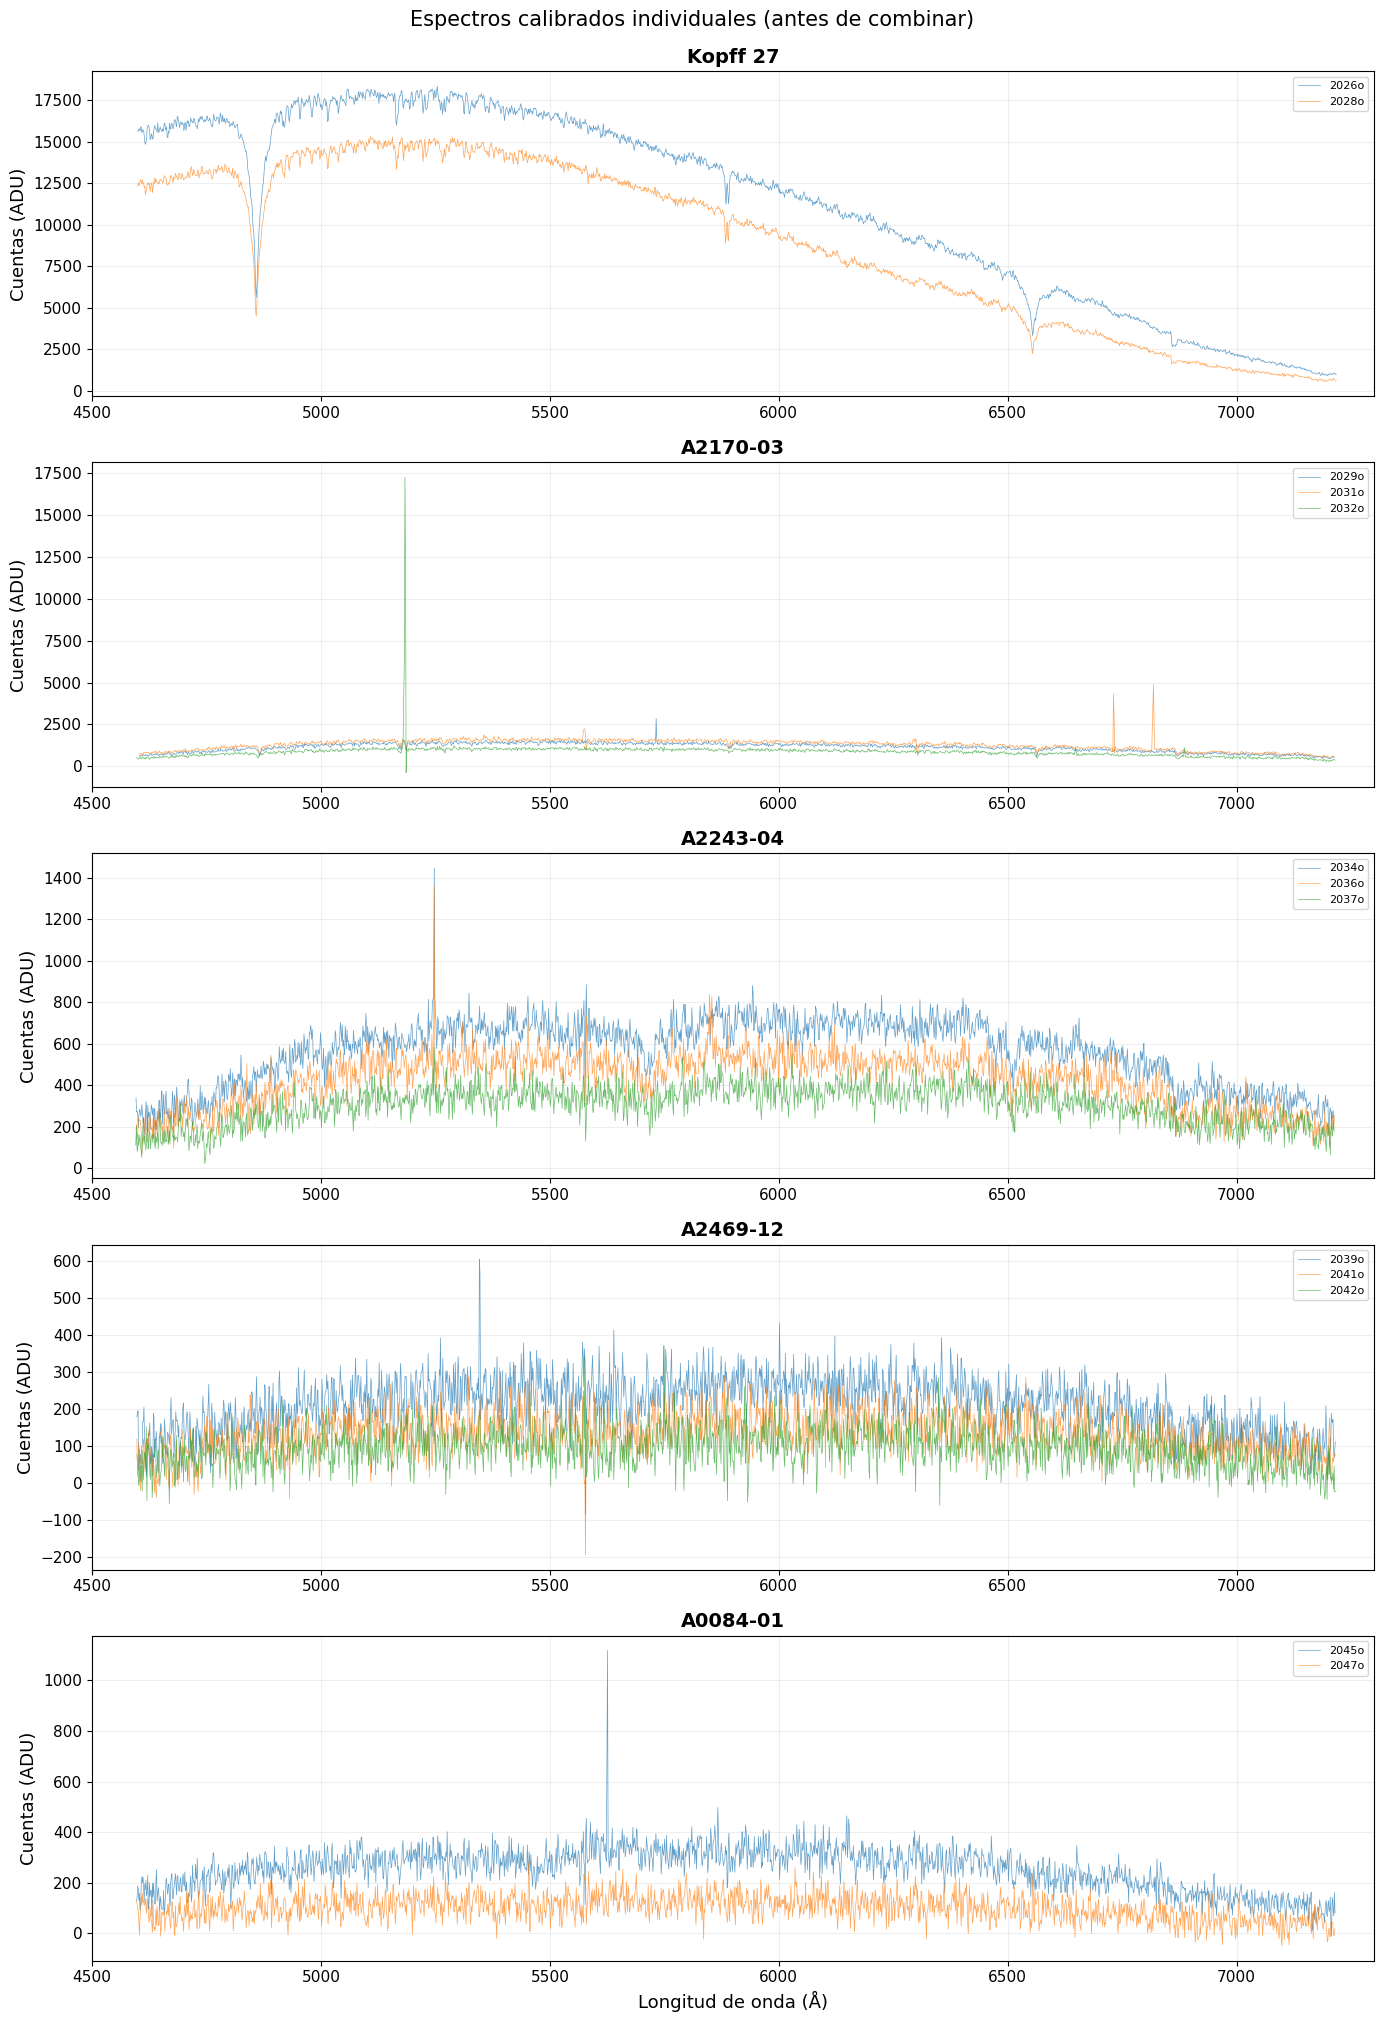

In [13]:
# Espectros calibrados individuales (antes de sumar)
# Mapeo: objeto -> archivos de la primera apertura
espectros_por_objeto = {
    'Kopff 27': ['2026o_tbfic_l.ms.fits', '2028o_tbfic_l.ms.fits'],
    'A2170-03': ['2029o_tbfic_l.ms.fits', '2031o_tbfic_l.ms.fits', '2032o_tbfic_l.ms.fits'],
    'A2243-04': ['2034o_tbfic_l.ms.fits', '2036o_tbfic_l.ms.fits', '2037o_tbfic_l.ms.fits'],
    'A2469-12': ['2039o_tbfic_l.ms.fits', '2041o_tbfic_l.ms.fits', '2042o_tbfic_l.ms.fits'],
    'A0084-01': ['2045o_tbfic_l.ms.fits', '2047o_tbfic_l.ms.fits'],
}

fig, axes = plt.subplots(5, 1, figsize=(14, 20))

for ax, (obj, archivos) in zip(axes, espectros_por_objeto.items()):
    for i, archivo in enumerate(archivos):
        fpath = os.path.join(NOCHE2, archivo)
        if os.path.exists(fpath):
            w, f = read_multispec_wavelength(fpath)
            ax.plot(w, f, lw=0.5, alpha=0.7, label=archivo.replace('_tbfic_l.ms.fits',''))
        else:
            print(f"No encontrado: {fpath}")

    ax.set_ylabel('Cuentas (ADU)')
    ax.set_title(f'{obj}', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(4500, 7300)

axes[-1].set_xlabel('Longitud de onda (Å)')
plt.tight_layout()
plt.suptitle('Espectros calibrados individuales (antes de combinar)', fontsize=15, y=1.01)
plt.show()

### 5.1 Espectros combinados (sumados)

Los espectros individuales de cada objeto se combinaron con `scombine` para mejorar la relación señal-a-ruido. Estos son los espectros finales sobre los que se midieron las velocidades radiales.

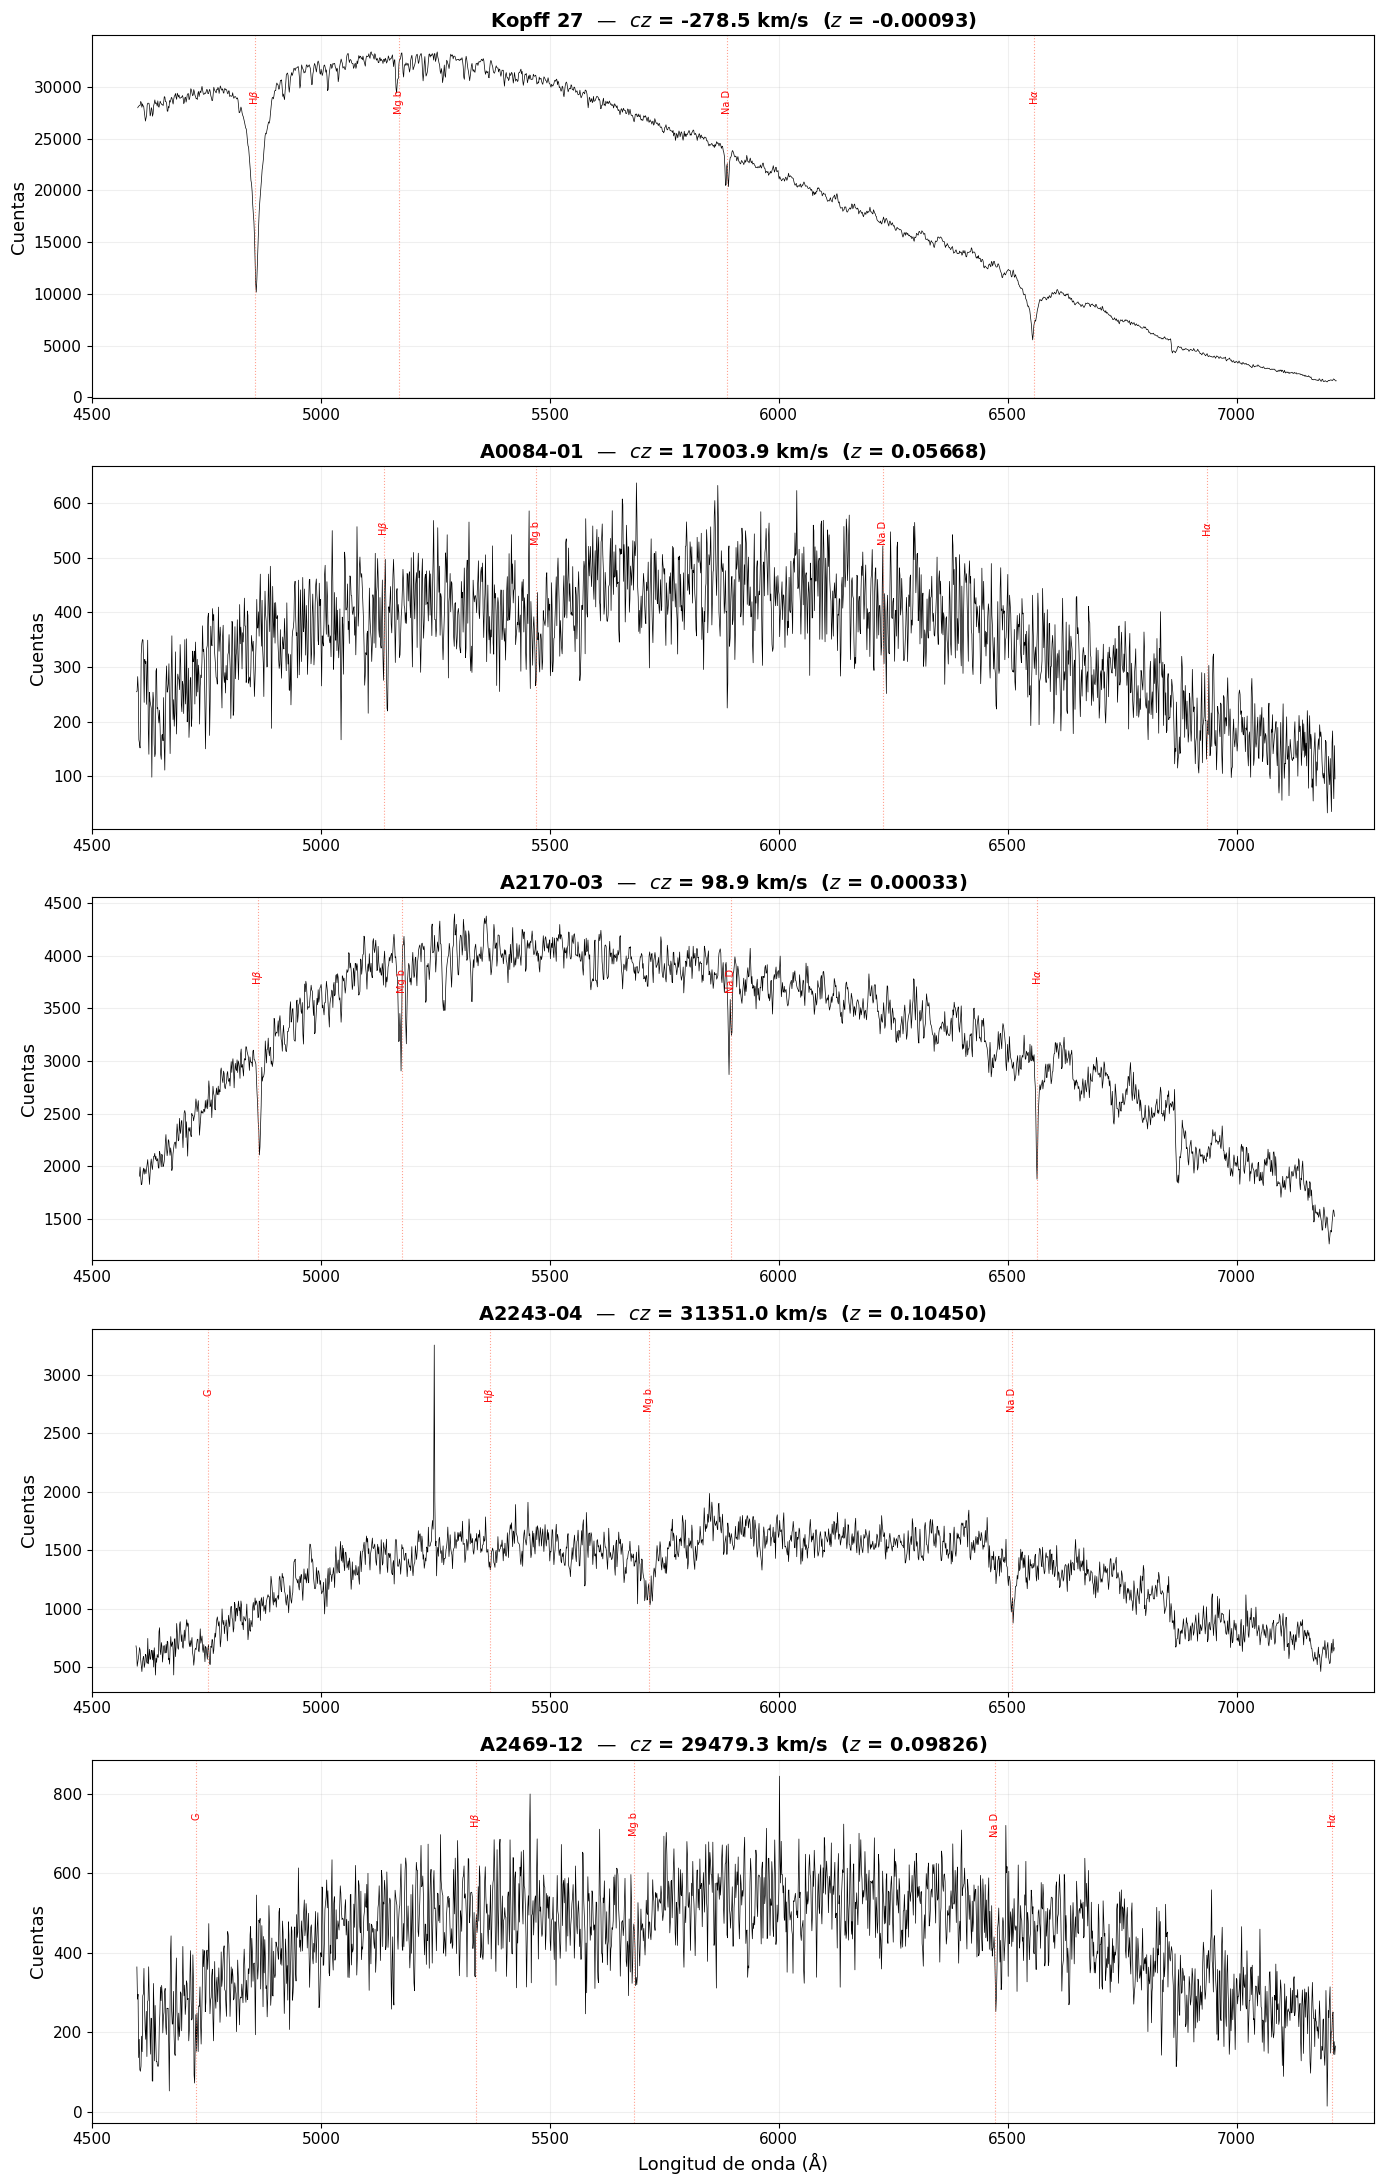

In [15]:
# Espectros sumados
espectros_sum = {
    'Kopff 27': os.path.join(INDIV, 'kopff27_sum.fits'),
    'A0084-01': os.path.join(INDIV, 'A0084-01_sum.fits'),
    'A2170-03': os.path.join(INDIV, 'A2170-03_sum.fits'),
    'A2243-04': os.path.join(INDIV, 'A2243-04_sum.fits'),
    'A2469-12': os.path.join(INDIV, 'A2469-12_sum.fits'),
}

# Líneas de absorción comunes en galaxias early-type (rest frame)
lineas_abs = {
    'Ca K': 3933.7, 'Ca H': 3968.5, 'G': 4304.4,
    r'H$\beta$': 4861.3, 'Mg b': 5175.4,
    'Na D': 5893.0, r'H$\alpha$': 6562.8
}

fig, axes = plt.subplots(5, 1, figsize=(14, 22))

cz_medido = {'Kopff 27': -278.5, 'A0084-01': 17003.9,
             'A2170-03': 98.9, 'A2243-04': 31351.0, 'A2469-12': 29479.3}

for ax, (obj, fpath) in zip(axes, espectros_sum.items()):
    if os.path.exists(fpath):
        w, f = read_multispec_wavelength(fpath)
        ax.plot(w, f, 'k-', lw=0.5)

        # Marcar líneas desplazadas al redshift medido
        z = cz_medido[obj] / 3e5
        for nombre, lam0 in lineas_abs.items():
            lam_obs = lam0 * (1 + z)
            if w[0] < lam_obs < w[-1]:
                ax.axvline(lam_obs, color='tomato', ls=':', lw=0.8, alpha=0.6)
                ypos = ax.get_ylim()[1] * 0.85
                ax.text(lam_obs, ypos, nombre, fontsize=7, color='red',
                        ha='center', va='top', rotation=90)
    else:
        ax.text(0.5, 0.5, f'{fpath}\nno encontrado', ha='center', va='center',
                transform=ax.transAxes)

    ax.set_ylabel('Cuentas')
    cz = cz_medido[obj]
    ax.set_title(f'{obj}  —  $cz$ = {cz:.1f} km/s  ($z$ = {cz/3e5:.5f})', fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(4500, 7300)

axes[-1].set_xlabel('Longitud de onda (Å)')
plt.tight_layout()
plt.show()

## 6. Velocidades Radiales — Resultados de `xcsao`

### 6.1 Tabla de resultados

Las velocidades radiales se midieron con la tarea `xcsao` del paquete RVSAO, utilizando correlación cruzada con múltiples templates espectrales del directorio `rvsao$Templates/`. El parámetro $R$ de Tonry & Davis (1979) cuantifica la confianza de la detección:

- $R < 3$: no confiable
- $3 < R < 4$: marginal
- $R > 4$: confiable

In [16]:
# Resultados de xcsao
resultados = Table()
resultados['Objeto'] = ['Kopff 27', 'A0084-01', 'A2170-03', 'A2243-04', 'A2469-12']
resultados['Mejor template'] = ['habtemp0', 'eltemp', 'fs2temp', 'fn4486b', 'habtemp90']
resultados['cz_medido (km/s)'] = [-278.5, 17003.9, 98.9, 31351.0, 29479.3]
resultados['error (km/s)'] = [55.8, 48.2, 15.9, 33.3, 56.1]
resultados['R'] = [6.20, 5.05, 12.48, 9.24, 5.24]
resultados['cz_pub (km/s)'] = [-15.05, 12592, 29532, 30129, 37601]
resultados['Delta_cz (km/s)'] = [
    -278.5 - (-15.05), 17003.9 - 12592, 98.9 - 29532,
    31351.0 - 30129, 29479.3 - 37601
]
resultados['Clasificacion'] = ['Discrepante', 'Galaxia', 'Estrella foreground', 'Galaxia', 'Galaxia']

resultados.pprint_all()

 Objeto  Mejor template cz_medido (km/s) error (km/s)   R   cz_pub (km/s)  Delta_cz (km/s)      Clasificacion   
-------- -------------- ---------------- ------------ ----- ------------- ------------------ -------------------
Kopff 27       habtemp0           -278.5         55.8   6.2        -15.05            -263.45         Discrepante
A0084-01         eltemp          17003.9         48.2  5.05       12592.0 4411.9000000000015             Galaxia
A2170-03        fs2temp             98.9         15.9 12.48       29532.0           -29433.1 Estrella foreground
A2243-04        fn4486b          31351.0         33.3  9.24       30129.0             1222.0             Galaxia
A2469-12      habtemp90          29479.3         56.1  5.24       37601.0 -8121.700000000001             Galaxia


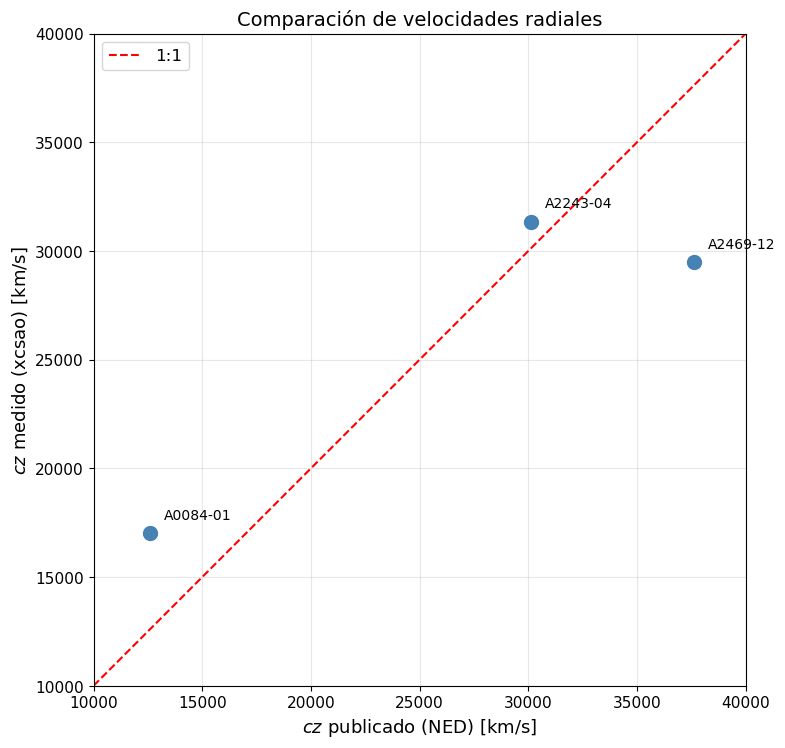


Diferencias cz_medido - cz_pub:
  A0084-01: +4411.9 km/s
  A2243-04: +1222.0 km/s
  A2469-12: -8121.7 km/s


In [17]:
# Comparación cz medido vs publicado (solo galaxias)
fig, ax = plt.subplots(figsize=(8, 8))

mask_gal = [False, True, False, True, True]  # Solo galaxias reales
nombres = np.array(resultados['Objeto'])[mask_gal]
cz_med = np.array(resultados['cz_medido (km/s)'])[mask_gal]
cz_pub = np.array(resultados['cz_pub (km/s)'])[mask_gal]
errores = np.array(resultados['error (km/s)'])[mask_gal]

ax.errorbar(cz_pub, cz_med, yerr=errores, fmt='o', ms=10, capsize=5,
            color='steelblue', ecolor='gray', zorder=3)

for i, nombre in enumerate(nombres):
    ax.annotate(nombre, (cz_pub[i], cz_med[i]), textcoords='offset points',
                xytext=(10, 10), fontsize=10)

# Línea 1:1
lims = [10000, 40000]
ax.plot(lims, lims, 'r--', lw=1.5, label='1:1')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('$cz$ publicado (NED) [km/s]')
ax.set_ylabel('$cz$ medido (xcsao) [km/s]')
ax.set_title('Comparación de velocidades radiales')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadística
print(f"\nDiferencias cz_medido - cz_pub:")
for n, m, p in zip(nombres, cz_med, cz_pub):
    print(f"  {n}: {m-p:+.1f} km/s")

### 6.2 Discusión: Kopff 27

La estrella Kopff 27 (IC 4665 27) fue incluida como estándar de velocidad radial. Sin embargo, se encontraron dos discrepancias significativas:

1. **Tipo espectral:** El espectro observado muestra líneas de absorción fuertes de Na D, Mg, CaFe, características de una estrella de tipo **K/G tardía**. Sin embargo, SIMBAD clasifica a Kopff 27 como **A3V**.

2. **Velocidad radial:** Se midió $cz = -278.5 \pm 55.8$ km/s, mientras que el valor publicado es $cz = -15.05 \pm 1.39$ km/s — una diferencia de ~263 km/s.

Las coordenadas de la bitácora de observación (17:41:28.4, +05:26:04, **época B1950**) coinciden con las coordenadas FK4 de Kopff 27 en SIMBAD (17:41:28.39, +05:26:04.23), confirmando que el apuntado fue correcto. La calibración en longitud de onda tiene un RMS de 0.09 Å (~5 km/s), insuficiente para explicar la discrepancia.

**La causa de estas discrepancias no se pudo determinar** durante este ejercicio. Posibilidades incluyen contaminación por otra estrella en la rendija o un problema no identificado en los datos originales. En consecuencia, **la verificación independiente de las velocidades radiales con un estándar no fue posible**.

> **Nota:** La calibración interna (RMS de las lámparas y consistencia entre templates) sugiere que las velocidades de las galaxias son confiables dentro de las incertidumbres reportadas por xcsao.

### 6.3 Discusión: A2170-03 — Estrella de campo

El objeto etiquetado como A2170-03 tiene $cz = 98.9 \pm 15.9$ km/s con $R = 12.48$. Esta velocidad corresponde a un objeto **galáctico**, no a una galaxia en el cúmulo Abell 2170 ($cz \sim 29\,500$ km/s). El S/N alto ($R > 12$) y la forma del espectro (continuo estelar con absorciones pronunciadas) confirman que se trata de una **estrella de campo** (foreground star) proyectada sobre el cúmulo.

Esto es consistente con la expectativa de que las rendijas en espectroscopía multiobjeto de cúmulos frecuentemente contienen estrellas de campo mezcladas con galaxias miembro.

### 6.4 Resumen de membresía a cúmulos

In [22]:
# Analisis de membresia
print('='*80)
print('ANALISIS DE VELOCIDADES RADIALES')
print('='*80)

cumulos = {
    'A0084-01': {'cumulo': 'Abell 84', 'cz_gal': 17003.9, 'cz_pub': 12592, 'tipo_z': 'photo-z',
                 'sigma_z_pub': 4500},
    'A2243-04': {'cumulo': 'Abell 2243', 'cz_gal': 31351.0, 'cz_pub': 30129, 'tipo_z': 'spec',
                 'sigma_z_pub': 100},
    'A2469-12': {'cumulo': 'Abell 2469', 'cz_gal': 29479.3, 'cz_pub': 37601, 'tipo_z': 'photo-z',
                 'sigma_z_pub': 4500},
}

for obj, info in cumulos.items():
    delta = info['cz_gal'] - info['cz_pub']
    z_gal = info['cz_gal'] / 3e5
    print(f"\n{obj} en {info['cumulo']}:")
    print(f"  cz medido (este trabajo) = {info['cz_gal']:.1f} km/s (z = {z_gal:.5f})")
    print(f"  cz publicado (NED)       = {info['cz_pub']:.0f} km/s [{info['tipo_z']}, sigma ~ {info['sigma_z_pub']} km/s]")
    print(f"  Diferencia               = {delta:+.1f} km/s")
    if info['tipo_z'] == 'photo-z':
        if abs(delta) < info['sigma_z_pub']:
            print(f"  -> Diferencia DENTRO de la incertidumbre del photo-z.")
        else:
            print(f"  -> Diferencia mayor que sigma del photo-z.")
    else:
        if abs(delta) < 2000:
            print(f"  -> Consistente con dispersion de velocidades del cumulo (~1000-1500 km/s)")
        else:
            print(f"  -> Diferencia significativa, verificar membresia")

ANALISIS DE VELOCIDADES RADIALES

A0084-01 en Abell 84:
  cz medido (este trabajo) = 17003.9 km/s (z = 0.05668)
  cz publicado (NED)       = 12592 km/s [photo-z, sigma ~ 4500 km/s]
  Diferencia               = +4411.9 km/s
  -> Diferencia DENTRO de la incertidumbre del photo-z.

A2243-04 en Abell 2243:
  cz medido (este trabajo) = 31351.0 km/s (z = 0.10450)
  cz publicado (NED)       = 30129 km/s [spec, sigma ~ 100 km/s]
  Diferencia               = +1222.0 km/s
  -> Consistente con dispersion de velocidades del cumulo (~1000-1500 km/s)

A2469-12 en Abell 2469:
  cz medido (este trabajo) = 29479.3 km/s (z = 0.09826)
  cz publicado (NED)       = 37601 km/s [photo-z, sigma ~ 4500 km/s]
  Diferencia               = -8121.7 km/s
  -> Diferencia mayor que sigma del photo-z.


## 7. Conclusiones

1. Se realizó la reducción completa de espectros de rendija larga obtenidos con el espectrógrafo B&Ch del telescopio de 2.1 m del OAN-SPM, incluyendo corrección de BIAS, flat field, extracción de aperturas, calibración en longitud de onda, y combinación de exposiciones.

2. La calibración en longitud de onda alcanzó un RMS de ~0.09 Å (~5 km/s de incertidumbre sistemática), verificado con las soluciones de `identify` en las lámparas de CuHeNeAr.

3. Se midieron velocidades radiales mediante correlación cruzada (`xcsao`, paquete RVSAO) con múltiples templates espectrales para 5 objetos:
   - **A0084-01:** $cz = 17\,004 \pm 48$ km/s ($R = 5.05$) — **posible primera medición espectroscópica**
   - **A2243-04:** $cz = 31\,351 \pm 33$ km/s ($R = 9.24$) — confirmada con $z$ espectroscópico previo
   - **A2469-12:** $cz = 29\,479 \pm 56$ km/s ($R = 5.24$) — **posible primera medición espectroscópica**
   - **A2170-03:** Estrella de campo foreground ($cz \approx 99$ km/s, $R = 12.48$)
   - **Kopff 27:** Resultado discrepante ($cz = -278$ km/s vs. $-15$ km/s publicado)

4. **Primeras mediciones espectroscópicas:** Para A0084-01 y A2469-12, los únicos redshifts disponibles en NED provenían del catálogo 2MPZ (Bilicki et al. 2014, ApJS, 210, 9), que son redshifts **fotométricos** con incertidumbre típica de $\sigma_z \approx 0.015$ (~4500 km/s). Las presentes mediciones espectroscópicas, con errores de ~50 km/s, representan una mejora de dos órdenes de magnitud en precisión.

5. **A2243-04 (ACO 2243):** La velocidad medida ($cz = 31\,351$ km/s) es consistente con el redshift espectroscópico publicado ($cz = 30\,129$ km/s) dentro de ~1200 km/s, compatible con la dispersión de velocidades de un cúmulo rico.

6. **A2170-03:** El espectro está dominado por una estrella de campo foreground proyectada sobre el campo del cúmulo Abell 2170, impidiendo la medición de la galaxia subyacente (LEDA 1684720).

7. **Kopff 27:** La estrella estándar de velocidad radial presentó discrepancias tanto en tipo espectral (K/G observado vs. A3V catalogado) como en velocidad radial ($\Delta cz \approx 263$ km/s), impidiendo la verificación independiente de la calibración. La consistencia interna de las lámparas de calibración (RMS ~ 0.09 Å) sustenta la confiabilidad de los resultados.

---

**Referencias:**
- Tonry, J. & Davis, M. 1979, AJ, 84, 1511 — Definición del parámetro $R$ para correlación cruzada.
- Kurtz, M. J. & Mink, D. J. 1998, PASP, 110, 934 — Paquete RVSAO.
- Bilicki, M. et al. 2014, ApJS, 210, 9 — 2MASS Photometric Redshift Catalog (2MPZ).
- Paturel, G. et al. 2003, A&A, 412, 45 — HYPERLEDA: Identificación y designación de galaxias.
- Struble, M. F. & Rood, H. J. 1999, ApJS, 125, 35 — Compilación de redshifts de cúmulos ACO.
- Chow-Martínez, M., Andernach, H., Caretta, C. A. & Trejo-Alonso, J. J. 2014, MNRAS, 445, 4073 — Catálogos de supercúmulos de Abell/ACO.